Heuristic Baseline Results
----------------------------------------
Accuracy: 0.5874047619047619
F1 weighted: 0.44954955929556334
F1 macro: 0.35128193181459294
Recall High: 0.22441694431223227

Classification Report:
              precision    recall  f1-score   support

         Low       0.59      0.98      0.74     73983
      Medium       0.21      0.01      0.01     47815
        High       0.46      0.22      0.30      4202

    accuracy                           0.59    126000
   macro avg       0.42      0.40      0.35    126000
weighted avg       0.44      0.59      0.45    126000



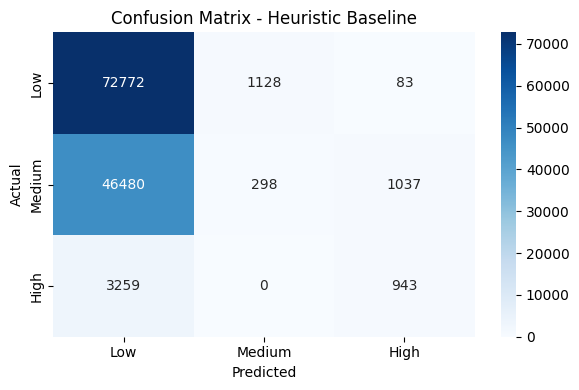

,model,accuracy,f1_weighted,f1_macro,recall_high
0,Heuristic Baseline,0.587405,0.44955,0.351282,0.224417


In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix
)

RSEED = 50

# 1. Load data
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

# 2. Train-validation split
train_sub_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["Irrigation_Need"],
    random_state=RSEED
)

# 3. Features and target
baseline_features = [
    "Rainfall_mm",
    "Wind_Speed_kmh",
    "Soil_Moisture",
    "Temperature_C"
]

X_train_final = train_sub_df[baseline_features]
X_val_final = val_df[baseline_features]

target_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

y_val_true = val_df["Irrigation_Need"].map(target_mapping)

# 4. Calculate thresholds only from training subset
rf_low, rf_high = X_train_final["Rainfall_mm"].quantile([0.33, 0.66])
sm_low, sm_high = X_train_final["Soil_Moisture"].quantile([0.33, 0.66])
temp_low, temp_high = X_train_final["Temperature_C"].quantile([0.33, 0.66])
ws_low, ws_high = X_train_final["Wind_Speed_kmh"].quantile([0.33, 0.66])

# 5. Heuristic baseline model
def heuristic_model(row):
    
    Rainfall = row["Rainfall_mm"]
    Soil_Moisture = row["Soil_Moisture"]
    Temperature = row["Temperature_C"]
    Wind_Speed = row["Wind_Speed_kmh"]
    
    if (
        (Soil_Moisture < sm_low)
        and (Temperature > temp_high)
        and (Rainfall < rf_low)
        and (Wind_Speed > ws_high)
    ):
        return 2  # High need for irrigation

    elif (
        (sm_low <= Soil_Moisture <= sm_high)
        and (temp_low <= Temperature <= temp_high)
        and (rf_low <= Rainfall <= rf_high)
        and (ws_low <= Wind_Speed <= ws_high)
    ):
        return 1  # Medium need for irrigation

    else:
        return 0  # Low need for irrigation

# Apply baseline model to validation set
y_val_pred = X_val_final.apply(heuristic_model, axis=1)

# 6. Evaluation
labels = [0, 1, 2]
target_names = ["Low", "Medium", "High"]

print("Heuristic Baseline Results")
print("-" * 40)

print("Accuracy:", accuracy_score(y_val_true, y_val_pred))
print("F1 weighted:", f1_score(y_val_true, y_val_pred, average="weighted"))
print("F1 macro:", f1_score(y_val_true, y_val_pred, average="macro"))

high_recall = recall_score(
    y_val_true,
    y_val_pred,
    labels=[2],
    average=None
)[0]

print("Recall High:", high_recall)

print("\nClassification Report:")
print(
    classification_report(
        y_val_true,
        y_val_pred,
        labels=labels,
        target_names=target_names
    )
)

# 7. Confusion matrix
cm = confusion_matrix(y_val_true, y_val_pred, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Heuristic Baseline")
plt.tight_layout()
plt.show()

# 8. Save validation results
os.makedirs("results", exist_ok=True)

baseline_results = pd.DataFrame({
    "model": ["Heuristic Baseline"],
    "accuracy": [accuracy_score(y_val_true, y_val_pred)],
    "f1_weighted": [f1_score(y_val_true, y_val_pred, average="weighted")],
    "f1_macro": [f1_score(y_val_true, y_val_pred, average="macro")],
    "recall_high": [high_recall]
})

baseline_results.to_csv("results/baseline_results.csv", index=False)

baseline_results

In [2]:
#KNN
categorical_cols = [
    "Soil_Type", "Crop_Type", "Crop_Growth_Stage",
    "Season", "Irrigation_Type", "Water_Source", "Region"
]

numerical_cols = [
    "Soil_pH", "Soil_Moisture", "Organic_Carbon",
    "Electrical_Conductivity", "Temperature_C", "Humidity",
    "Rainfall_mm", "Sunlight_Hours", "Wind_Speed_kmh",
    "Field_Area_hectare", "Previous_Irrigation_mm"
]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_knn = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

knn_pipeline = Pipeline([
    ("preprocessing", preprocessor_knn),
    ("smote", SMOTE(random_state=RSEED)),
    ("model", KNeighborsClassifier())
])

from sklearn.model_selection import RandomizedSearchCV

param_dist_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 15],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]  # Manhattan vs Euclidean
}

knn_search = RandomizedSearchCV(
    knn_pipeline,
    param_distributions=param_dist_knn,
    n_iter=10,
    scoring="f1_weighted",
    cv=3,
    random_state=RSEED,
    n_jobs=-1
)
X_train = train_sub_df.drop(columns=["Irrigation_Need", "id"])
y_train = train_sub_df["Irrigation_Need"]

X_val = val_df.drop(columns=["Irrigation_Need", "id"])
y_val = val_df["Irrigation_Need"]

knn_search.fit(X_train, y_train)

best_knn = knn_search.best_estimator_

from sklearn.metrics import accuracy_score, f1_score, recall_score

y_pred_knn = best_knn.predict(X_val)

print("KNN Results")
print("Accuracy:", accuracy_score(y_val, y_pred_knn))
print("F1 weighted:", f1_score(y_val, y_pred_knn, average="weighted"))

high_recall = recall_score(
    y_val,
    y_pred_knn,
    labels=["High"],
    average=None
)[0]

print("Recall High:", high_recall)

c:\Users\X1 Yoga\Ginger_Gradient\ds-ml-project\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [0.77391479        nan 0.79235176 0.77397793 0.75297356 0.77700305
 0.76487225 0.75176849 0.80300459 0.76757621]
  warnings.warn(


KNN Results
Accuracy: 0.7927380952380952
F1 weighted: 0.8054502445983066
Recall High: 0.7451213707758211


In [6]:
from sklearn.metrics import f1_score

f1_macro = f1_score(y_val, y_pred_knn, average="macro")

print("F1 macro:", f1_macro)

pd.DataFrame(knn_search.cv_results_)[
    ["params", "mean_test_score", "rank_test_score"]
].sort_values("mean_test_score", ascending=False)

print(knn_search.best_params_)
print(knn_search.best_score_)

F1 macro: 0.6659012028039061
{'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': 15}
0.8030045928173655


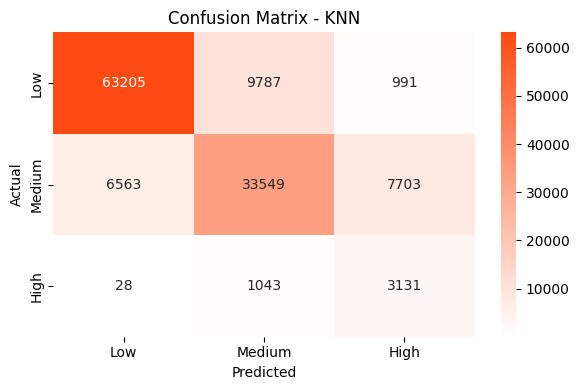

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_red",
    ["#ffffff", "#FF4A11"]  # weiß → dein Orange/Rot
)
labels = ["Low", "Medium", "High"]

cm = confusion_matrix(y_val, y_pred_knn, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=custom_cmap,
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")
plt.tight_layout()
plt.show()

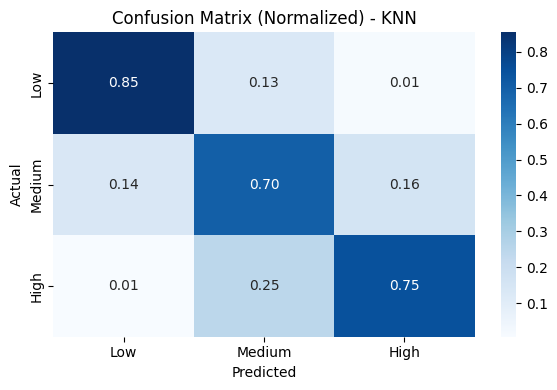

In [5]:
cm_norm = confusion_matrix(y_val, y_pred_knn, labels=labels, normalize="true")

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Normalized) - KNN")
plt.tight_layout()
plt.show()

In [31]:
#xgboost
import os
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix

from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

RSEED = 50
np.random.seed(RSEED)
random.seed(RSEED)

train_df = pd.read_csv("data/train.csv")

train_sub_df, val_df = train_test_split(
    train_df,
    test_size=0.3,
    stratify=train_df["Irrigation_Need"],
    random_state=RSEED
)

X_train = train_sub_df.drop(columns=["Irrigation_Need", "id"])
X_val = val_df.drop(columns=["Irrigation_Need", "id"])

y_train = train_sub_df["Irrigation_Need"]
y_val = val_df["Irrigation_Need"]

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols)
    ]
)

In [33]:
xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softmax",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RSEED,
        n_jobs=-1
    ))
])

param_dist_xgb = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    random_state=RSEED,
    n_jobs=-1,
    verbose=2
)

xgb_search.fit(X_train, y_train_enc)

best_xgb = xgb_search.best_estimator_

print("Best parameters:")
print(xgb_search.best_params_)
print("Best CV score:", xgb_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters:
{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}
Best CV score: 0.9693647951136382


In [34]:
y_pred_xgb_enc = best_xgb.predict(X_val)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

labels = ["Low", "Medium", "High"]

xgb_accuracy = accuracy_score(y_val, y_pred_xgb)
xgb_f1_weighted = f1_score(y_val, y_pred_xgb, average="weighted")
xgb_f1_macro = f1_score(y_val, y_pred_xgb, average="macro")
xgb_recall_high = recall_score(y_val, y_pred_xgb, labels=["High"], average=None)[0]

print("XGBoost without SMOTE")
print("-" * 40)
print("Accuracy:", xgb_accuracy)
print("F1 weighted:", xgb_f1_weighted)
print("F1 macro:", xgb_f1_macro)
print("Recall High:", xgb_recall_high)

print(classification_report(y_val, y_pred_xgb, labels=labels))

XGBoost without SMOTE
----------------------------------------
Accuracy: 0.9842962962962963
F1 weighted: 0.984228797808752
F1 macro: 0.9700810485283452
Recall High: 0.9154370934475646
              precision    recall  f1-score   support

         Low       0.98      1.00      0.99    110975
      Medium       0.98      0.97      0.98     71722
        High       0.97      0.92      0.94      6303

    accuracy                           0.98    189000
   macro avg       0.98      0.96      0.97    189000
weighted avg       0.98      0.98      0.98    189000



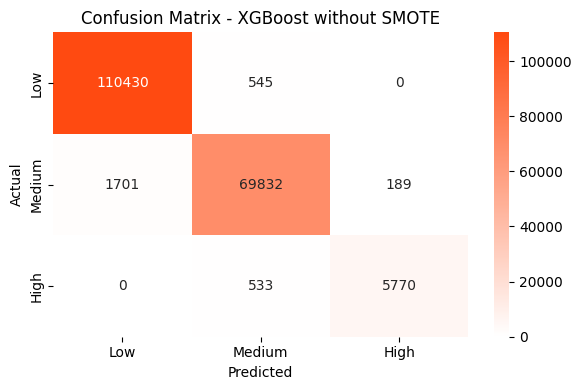

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred_xgb, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=custom_cmap,
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost without SMOTE")
plt.tight_layout()
plt.show()

In [36]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

best_params = xgb_search.best_params_

xgb_smote_pipeline = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=RSEED)),
    ("model", XGBClassifier(
        objective="multi:softmax",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RSEED,
        n_jobs=-1,
        n_estimators=best_params["model__n_estimators"],
        max_depth=best_params["model__max_depth"],
        learning_rate=best_params["model__learning_rate"],
        subsample=best_params["model__subsample"],
        colsample_bytree=best_params["model__colsample_bytree"]
    ))
])

xgb_smote_pipeline.fit(X_train, y_train_enc)

y_pred_xgb_smote_enc = xgb_smote_pipeline.predict(X_val)
y_pred_xgb_smote = le.inverse_transform(y_pred_xgb_smote_enc)

In [37]:
xgb_smote_accuracy = accuracy_score(y_val, y_pred_xgb_smote)
xgb_smote_f1_weighted = f1_score(y_val, y_pred_xgb_smote, average="weighted")
xgb_smote_f1_macro = f1_score(y_val, y_pred_xgb_smote, average="macro")
xgb_smote_recall_high = recall_score(y_val, y_pred_xgb_smote, labels=["High"], average=None)[0]

print("XGBoost with SMOTE")
print("-" * 40)
print("Accuracy:", xgb_smote_accuracy)
print("F1 weighted:", xgb_smote_f1_weighted)
print("F1 macro:", xgb_smote_f1_macro)
print("Recall High:", xgb_smote_recall_high)

print(classification_report(y_val, y_pred_xgb_smote, labels=labels))

XGBoost with SMOTE
----------------------------------------
Accuracy: 0.9838571428571429
F1 weighted: 0.9837994039349826
F1 macro: 0.9687611230803009
Recall High: 0.9203553863239727
              precision    recall  f1-score   support

         Low       0.98      0.99      0.99    110975
      Medium       0.98      0.97      0.98     71722
        High       0.96      0.92      0.94      6303

    accuracy                           0.98    189000
   macro avg       0.98      0.96      0.97    189000
weighted avg       0.98      0.98      0.98    189000



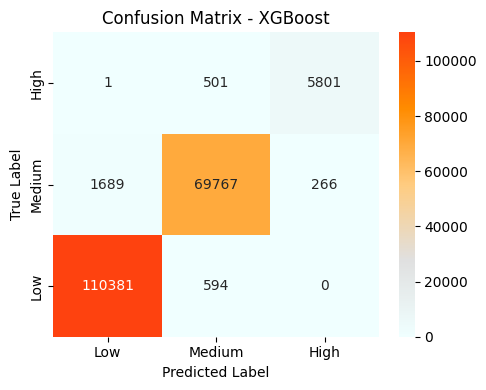

In [55]:
cm = confusion_matrix(y_val, y_pred_xgb_smote, labels=labels)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="",
    cmap=cmap,
    xticklabels=labels,
    yticklabels=labels
)
plt.gca().invert_yaxis()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()

In [14]:
xgb_results = pd.DataFrame({
    "model": ["XGBoost", "XGBoost + SMOTE"],
    "accuracy": [xgb_accuracy, xgb_smote_accuracy],
    "f1_weighted": [xgb_f1_weighted, xgb_smote_f1_weighted],
    "f1_macro": [xgb_f1_macro, xgb_smote_f1_macro],
    "recall_high": [xgb_recall_high, xgb_smote_recall_high]
})

os.makedirs("results", exist_ok=True)
xgb_results.to_csv("results/xgboost_results.csv", index=False)

xgb_results

,model,accuracy,f1_weighted,f1_macro,recall_high
0,XGBoost,0.983651,0.983582,0.969872,0.915040
1,XGBoost + SMOTE,0.983746,0.983690,0.969546,0.922418


In [25]:
best_knn_params = {
    "n_neighbors": 15,
    "weights": "distance",
    "p": 1
}


In [39]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

train_sub_df, val_df = train_test_split(
    train_df,
    test_size=0.3,
    stratify=train_df["Irrigation_Need"],
    random_state=RSEED
)

X_train = train_sub_df.drop(columns=["Irrigation_Need", "id"])
X_val = val_df.drop(columns=["Irrigation_Need", "id"])

y_train = train_sub_df["Irrigation_Need"]
y_val = val_df["Irrigation_Need"]

preprocessor_knn = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)
knn_final = Pipeline([
    ("preprocessing", preprocessor_knn),
    ("smote", SMOTE(random_state=RSEED)),
    ("model", KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        p=1
    ))
])

knn_final.fit(X_train, y_train)

y_pred_knn = knn_final.predict(X_val)

In [40]:
print("Accuracy:", accuracy_score(y_val, y_pred_knn))
print("F1 weighted:", f1_score(y_val, y_pred_knn, average="weighted"))
print("F1 macro:", f1_score(y_val, y_pred_knn, average="macro"))
print("Recall High:", recall_score(y_val, y_pred_knn, labels=["High"], average=None)[0])

Accuracy: 0.7452063492063492
F1 weighted: 0.7641594198702825
F1 macro: 0.5998232377322371
Recall High: 0.5662382992225924


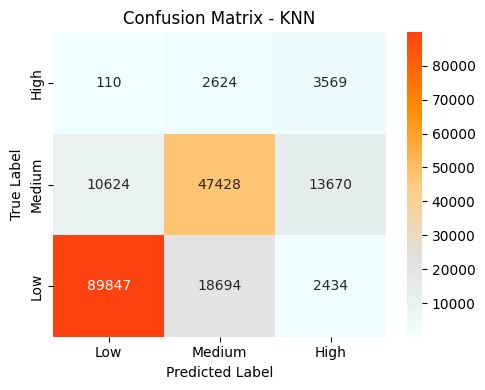

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    "gray_to_orange",
    ["#F0FFFF", "#E0E0E0", "#FFCC80", "#FF8C00", "#FE420F"]
)
labels = ["Low", "Medium", "High"]

cm = confusion_matrix(y_val, y_pred_knn, labels=labels)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="",
    cmap=cmap,
    xticklabels=labels,
    yticklabels=labels
)
plt.gca().invert_yaxis()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - KNN")
plt.tight_layout()
plt.show()